<a href="https://colab.research.google.com/github/anubhavsingh23906-code/IMDB-Sentiment-Analysis/blob/main/Imdb_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("IMDB Dataset.csv", engine='python', on_bad_lines='warn')

/tmp/ipykernel_3193/203254731.py:1: ParserWarning: Skipping line 3982: unexpected end of data

  df = pd.read_csv("IMDB Dataset.csv", engine='python', on_bad_lines='warn')


In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(3980, 2)

In [5]:
df['sentiment'].value_counts()

,count
sentiment,
negative,2012
positive,1968


In [6]:
df.sample(5)

,review,sentiment
1971,"First of all, we know that Bruce Willis is a g...",positive
2514,The defining scene to this movie is when the f...,negative
1939,"this could have been better,but it was alright...",negative
1690,Peter Cushing and Donald Pleasance are legenda...,negative
2502,I have seen a couple movies on eating disorder...,positive


In [7]:
df['review_length'] = df['review'].apply(len)

df['review_length'].describe()

,review_length
count,3980.000000
mean,1302.370603
std,980.094928
min,80.000000
25%,697.000000
50%,961.000000
75%,1604.250000
max,9951.000000


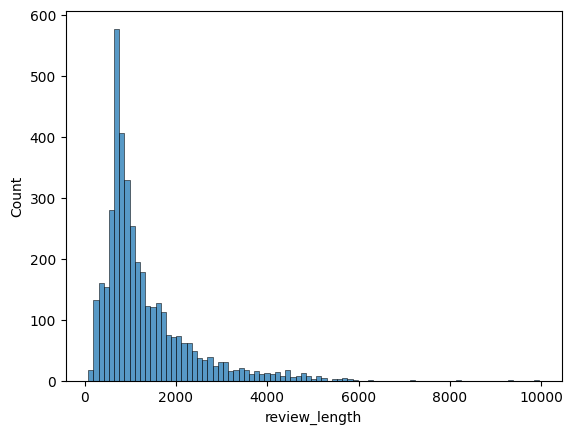

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['review_length'])
plt.show()

In [9]:
import re

In [10]:
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub('<.*?>', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

In [11]:
df['clean_review'] = df['review'].apply(clean_text)

In [12]:
print(df['review'][0])
print("="*100)
print(df['clean_review'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [13]:
df['review_length'] = df['clean_review'].apply(len)

In [14]:
df['review_length'].describe()

,review_length
count,3980.000000
mean,1234.661809
std,929.722003
min,76.000000
25%,661.000000
50%,915.000000
75%,1515.250000
max,9525.000000


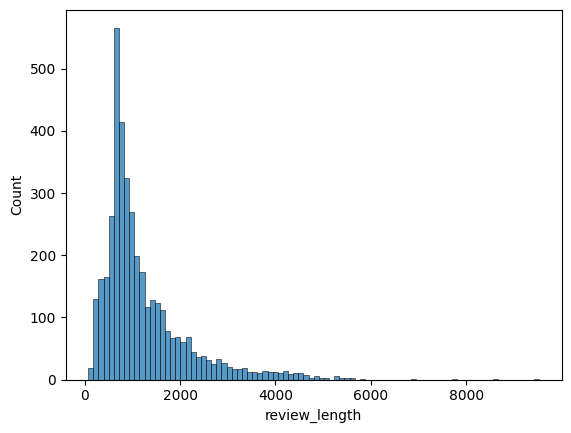

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['review_length'])
plt.show()

In [16]:
print(df['review'][0])
print(df['clean_review'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [17]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [18]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

print(list(stop_words)[:20])

['themselves', 'here', 'during', 'to', 'your', 'who', 'hers', 'o', "he's", "it'd", "it's", 'my', "we've", 'in', 'what', "we'd", "you've", "doesn't", 'between', "i'll"]


In [19]:
def remove_stopwords(text):

    words = text.split()

    filtered = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered)

In [20]:
df['clean_review'] = df['clean_review'].apply(remove_stopwords)

In [21]:
print(df['clean_review'][0])

one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home manyaryans muslims gangstas latinos christians italians irish moreso scuffles death stares dodgy dealings shady agreements never far awayi would say main appeal show due fact goes shows wouldnt dare forget pretty pictures painted mainstream audiences forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high levels graphic violence violence injustice crooked guards wholl sold nickel inmates wholl kill order get away well mannered middle cla

In [22]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

In [23]:
def stem_text(text):

    words = text.split()

    stemmed_words = [ps.stem(word) for word in words]

    return " ".join(stemmed_words)

In [24]:
df['clean_review'] = df['clean_review'].apply(stem_text)

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']

In [26]:
X.shape

(3980, 5000)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8668341708542714


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.86      0.89      0.87       410
    positive       0.87      0.85      0.86       386

    accuracy                           0.87       796
   macro avg       0.87      0.87      0.87       796
weighted avg       0.87      0.87      0.87       796



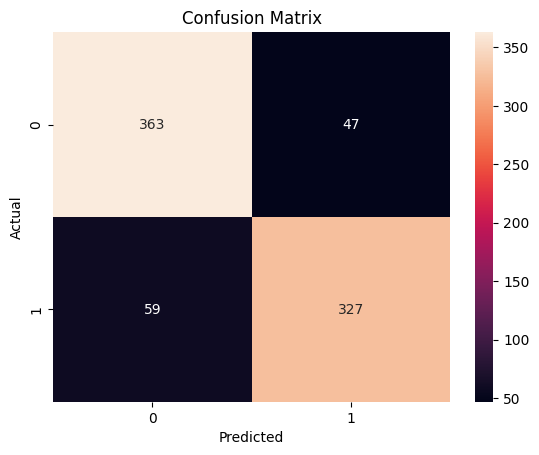

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

from sklearn.metrics import accuracy_score

print("NB Accuracy:", accuracy_score(y_test, nb_pred))

NB Accuracy: 0.8379396984924623


In [33]:
import joblib

joblib.dump(lr, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']